# Wunder Challenge - Exploratory Data Analysis

This notebook explores the training data to understand:
- Dataset structure and dimensions
- Sequence characteristics
- Feature distributions and statistics
- Temporal patterns
- Correlations and dependencies

In [1]:
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Add competition package to path
sys.path.append('../competition_package')
from utils import DataPoint, ScorerStepByStep

# Configure plotting
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
%matplotlib inline

# Display settings
pd.set_option('display.max_columns', 50)
pd.set_option('display.precision', 6)

## 1. Load Data

In [2]:
# Load training data
data_path = '../competition_package/datasets/train.parquet'
df = pd.read_parquet(data_path)

print(f"Dataset loaded: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Memory usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

Dataset loaded: 517,000 rows × 35 columns
Memory usage: 138.05 MB


## 2. Dataset Structure

In [3]:
# Basic info
print("Column names (first 20):")
print(df.columns[:20].tolist())
print(f"\nTotal columns: {len(df.columns)}")
print(f"\nData types:")
print(df.dtypes.value_counts())

Column names (first 20):
['seq_ix', 'step_in_seq', 'need_prediction', '0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13', '14', '15', '16']

Total columns: 35

Data types:
float64    32
int64       3
Name: count, dtype: int64


In [4]:
# Identify metadata vs feature columns
metadata_cols = ['seq_ix', 'step_in_seq', 'need_prediction']
feature_cols = [col for col in df.columns if col not in metadata_cols]
n_features = len(feature_cols)

print(f"Metadata columns: {metadata_cols}")
print(f"Number of features: {n_features}")
print(f"Feature columns: {feature_cols[:10]} ... {feature_cols[-3:]}")

Metadata columns: ['seq_ix', 'step_in_seq', 'need_prediction']
Number of features: 32
Feature columns: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9'] ... ['29', '30', '31']


## 3. Sequence Analysis

In [5]:
# Sequence statistics
n_sequences = df['seq_ix'].nunique()
seq_lengths = df.groupby('seq_ix').size()

print("=" * 70)
print("SEQUENCE STATISTICS")
print("=" * 70)
print(f"Number of sequences: {n_sequences}")
print(f"\nSequence lengths:")
print(seq_lengths.describe())
print(f"\nUnique sequence lengths: {seq_lengths.unique()}")

SEQUENCE STATISTICS
Number of sequences: 517

Sequence lengths:
count     517.0
mean     1000.0
std         0.0
min      1000.0
25%      1000.0
50%      1000.0
75%      1000.0
max      1000.0
dtype: float64

Unique sequence lengths: [1000]


In [6]:
# Step analysis
print("=" * 70)
print("STEP ANALYSIS")
print("=" * 70)
print(f"Step range: {df['step_in_seq'].min()} to {df['step_in_seq'].max()}")
print(f"\nStep distribution:")
print(df['step_in_seq'].value_counts().sort_index().head(10))

STEP ANALYSIS
Step range: 0 to 999

Step distribution:
step_in_seq
0    517
1    517
2    517
3    517
4    517
5    517
6    517
7    517
8    517
9    517
Name: count, dtype: int64


In [7]:
# Prediction flag analysis
pred_counts = df['need_prediction'].value_counts()
# Access by position instead of boolean key (pandas 2.0+ compatibility)
predictions_per_seq = pred_counts.iloc[pred_counts.index.tolist().index(True)] / n_sequences if True in pred_counts.index else 0
warmup_per_seq = pred_counts.iloc[pred_counts.index.tolist().index(False)] / n_sequences if False in pred_counts.index else 0

print("=" * 70)
print("PREDICTION FLAG DISTRIBUTION")
print("=" * 70)
print(pred_counts)
print(f"\nPer sequence:")
print(f"  Predictions needed: {predictions_per_seq:.0f}")
print(f"  Warm-up steps: {warmup_per_seq:.0f}")
print(f"  Total steps: {predictions_per_seq + warmup_per_seq:.0f}")

PREDICTION FLAG DISTRIBUTION
need_prediction
1    464783
0     52217
Name: count, dtype: int64

Per sequence:
  Predictions needed: 0
  Warm-up steps: 0
  Total steps: 0


## 4. Feature Statistics

In [8]:
# Overall feature statistics
feature_stats = df[feature_cols].describe().T
feature_stats['range'] = feature_stats['max'] - feature_stats['min']
feature_stats['cv'] = feature_stats['std'] / feature_stats['mean'].abs()  # Coefficient of variation

print("Feature statistics summary:")
print(feature_stats.head(10))

Feature statistics summary:
      count      mean       std       min       25%       50%       75%  \
0  517000.0  0.001247  0.985162 -5.199338 -0.672111 -0.003134  0.655925   
1  517000.0  0.022680  0.994129 -5.199338 -0.655956  0.013809  0.698124   
2  517000.0 -0.006079  1.008178 -5.199338 -0.680784 -0.006287  0.663186   
3  517000.0 -0.013578  1.010985 -5.199338 -0.703100 -0.020027  0.661700   
4  517000.0 -0.001519  0.990943 -5.199338 -0.684677 -0.003576  0.670718   
5  517000.0  0.006435  0.989856 -5.199338 -0.668105  0.009730  0.685277   
6  517000.0 -0.022507  1.001293 -5.199338 -0.709381 -0.018166  0.669402   
7  517000.0 -0.020070  0.997337 -5.199338 -0.681834 -0.005193  0.645322   
8  517000.0 -0.013120  0.999672 -5.199338 -0.678942 -0.011451  0.651335   
9  517000.0  0.011407  0.997744 -5.199338 -0.667408  0.004037  0.687519   

        max      range          cv  
0  5.199338  10.398675  789.991179  
1  5.199338  10.398675   43.833182  
2  5.199338  10.398675  165.847298 

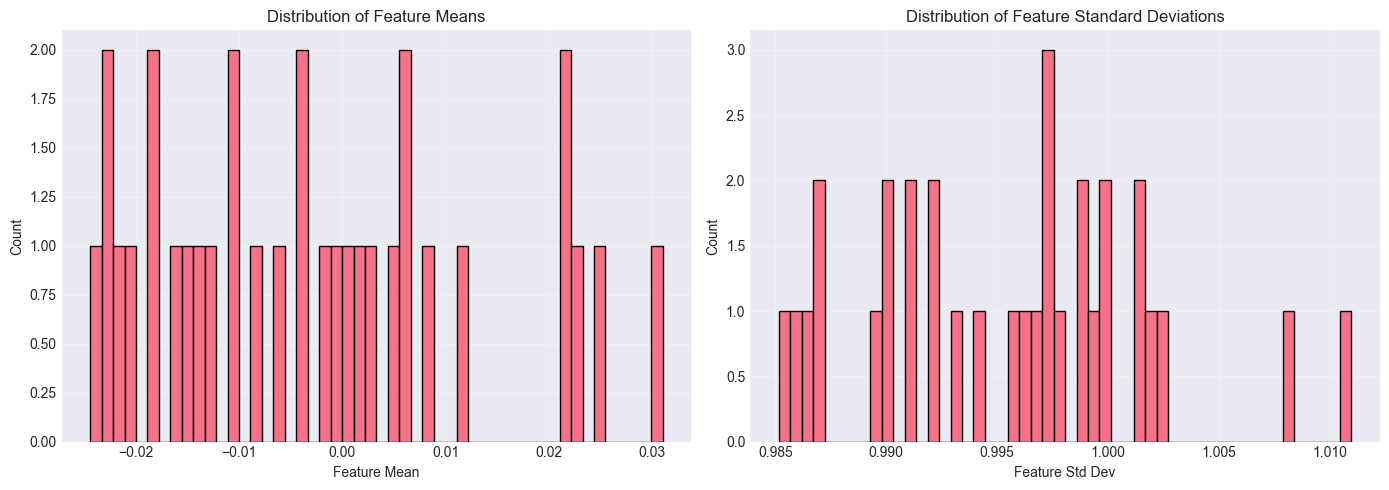

In [9]:
# Distribution of feature means and std devs
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(feature_stats['mean'], bins=50, edgecolor='black')
axes[0].set_xlabel('Feature Mean')
axes[0].set_ylabel('Count')
axes[0].set_title('Distribution of Feature Means')
axes[0].grid(True, alpha=0.3)

axes[1].hist(feature_stats['std'], bins=50, edgecolor='black')
axes[1].set_xlabel('Feature Std Dev')
axes[1].set_ylabel('Count')
axes[1].set_title('Distribution of Feature Standard Deviations')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [10]:
# Check for missing values
missing_counts = df[feature_cols].isnull().sum()
features_with_missing = missing_counts[missing_counts > 0]

print("=" * 70)
print("MISSING VALUES")
print("=" * 70)
if len(features_with_missing) > 0:
    print(f"Features with missing values: {len(features_with_missing)}")
    print(features_with_missing)
else:
    print("No missing values found!")

MISSING VALUES
No missing values found!


## 5. Sample Sequence Visualization

In [11]:
# Get first sequence
first_seq_ix = df['seq_ix'].min()
first_seq = df[df['seq_ix'] == first_seq_ix].copy()

print(f"First sequence (seq_ix={first_seq_ix}):")
print(first_seq[['seq_ix', 'step_in_seq', 'need_prediction'] + feature_cols[:5]].head(15))

First sequence (seq_ix=0):
    seq_ix  step_in_seq  need_prediction         0         1         2  \
0        0            0                0 -0.080082  1.324564  0.637730   
1        0            1                0 -1.243274  0.398425 -1.810485   
2        0            2                0 -0.124680  1.225580  0.139482   
3        0            3                0 -1.264455  0.494485 -1.041663   
4        0            4                0 -0.882663 -0.223168 -1.229349   
5        0            5                0  0.151475  0.987355  0.289646   
6        0            6                0  0.328206  0.731657  0.809983   
7        0            7                0 -1.189000  0.288322 -1.785559   
8        0            8                0  0.306474  0.817488  0.778954   
9        0            9                0  0.396739  0.635792  0.626691   
10       0           10                0  0.255535  0.899682  0.444749   
11       0           11                0  0.228332  0.966672  0.701910   
12       0 

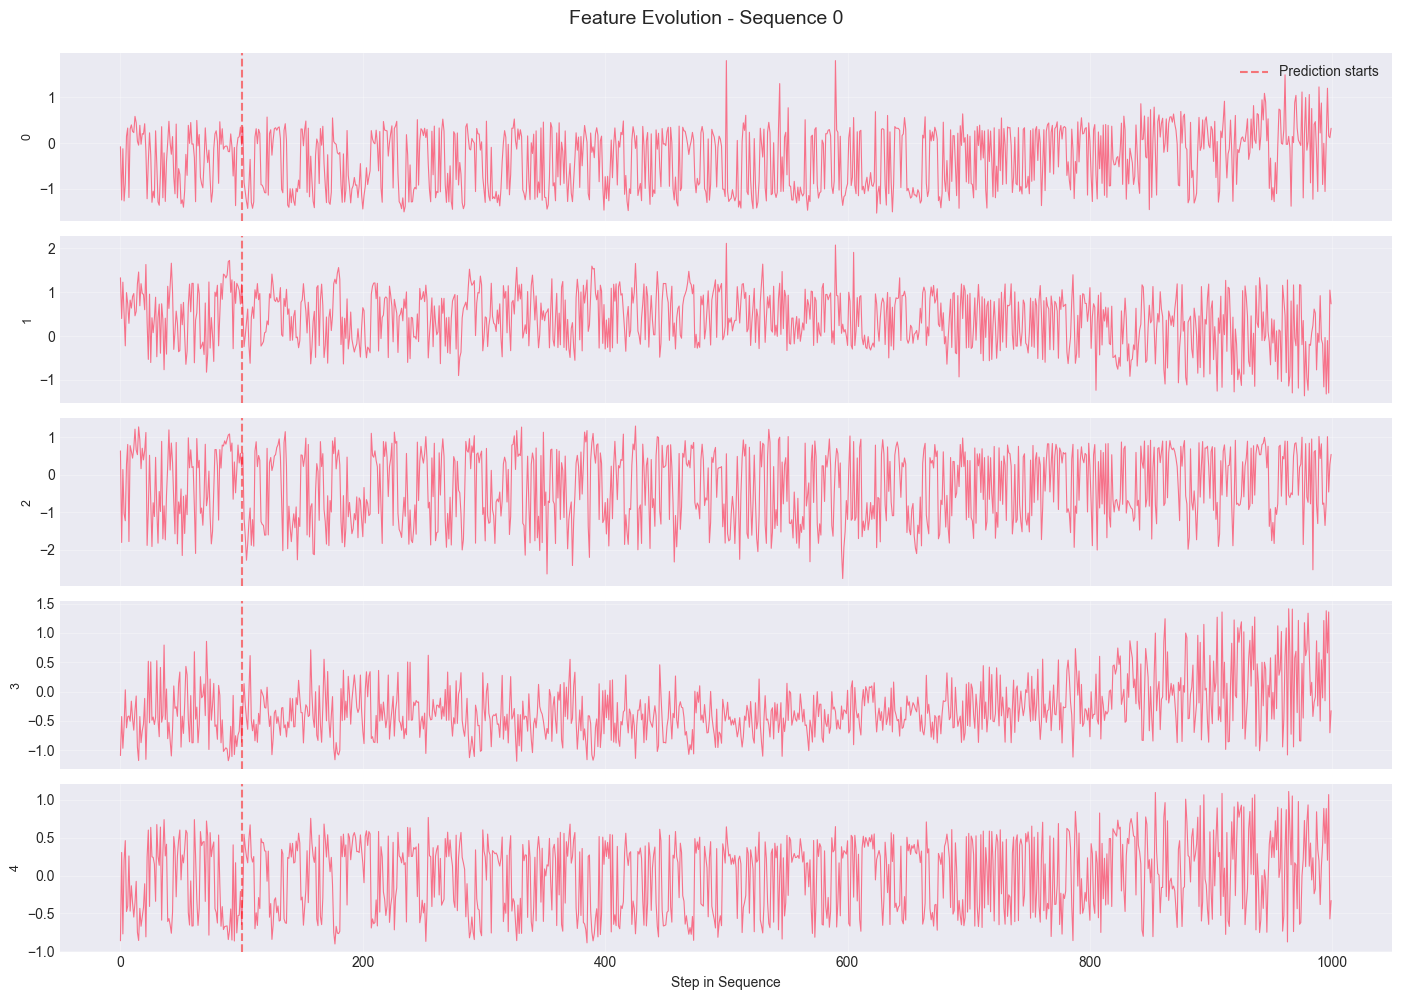

In [12]:
# Plot first 5 features over time for first sequence
fig, axes = plt.subplots(5, 1, figsize=(14, 10), sharex=True)

for i, feature in enumerate(feature_cols[:5]):
    axes[i].plot(first_seq['step_in_seq'], first_seq[feature], linewidth=0.8)
    axes[i].set_ylabel(feature, fontsize=9)
    axes[i].grid(True, alpha=0.3)
    axes[i].axvline(x=100, color='red', linestyle='--', alpha=0.5, label='Prediction starts')
    if i == 0:
        axes[i].legend(loc='upper right')

axes[-1].set_xlabel('Step in Sequence')
fig.suptitle(f'Feature Evolution - Sequence {first_seq_ix}', fontsize=14, y=0.995)
plt.tight_layout()
plt.show()

## 6. Temporal Patterns

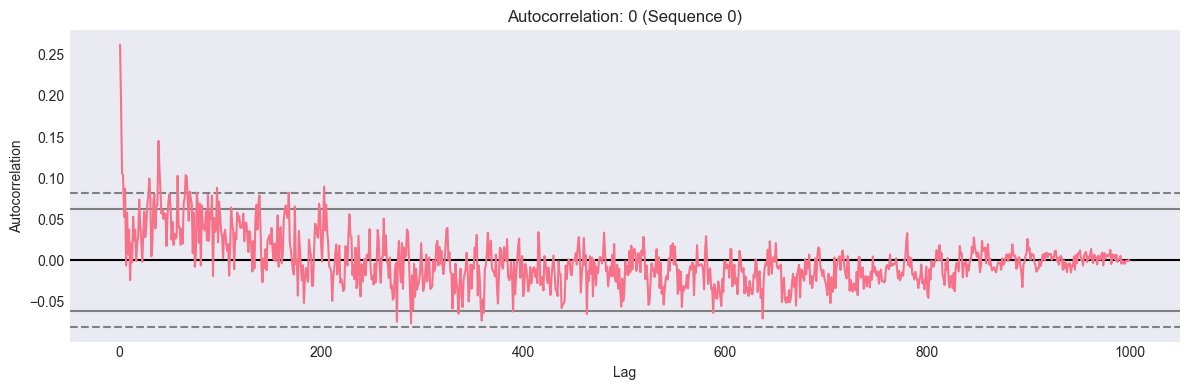

In [13]:
# Autocorrelation analysis for first feature
from pandas.plotting import autocorrelation_plot

fig, ax = plt.subplots(figsize=(12, 4))
autocorrelation_plot(first_seq[feature_cols[0]], ax=ax)
ax.set_title(f'Autocorrelation: {feature_cols[0]} (Sequence {first_seq_ix})')
ax.set_xlabel('Lag')
ax.set_ylabel('Autocorrelation')
plt.tight_layout()
plt.show()

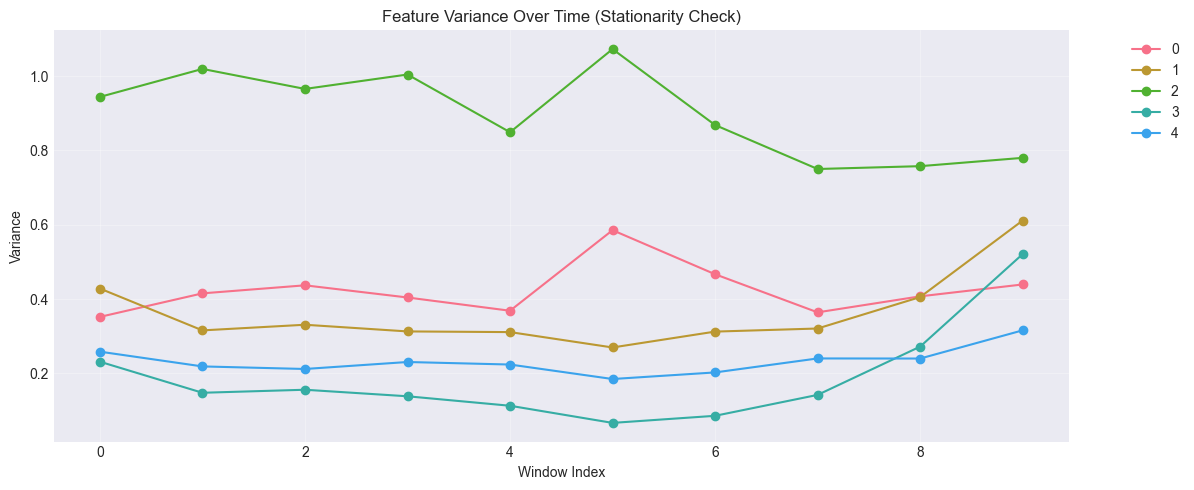

In [14]:
# Check if features are stationary (using variance over time)
# Split sequence into 10 windows and compute variance
window_size = len(first_seq) // 10
variances = []

for i in range(10):
    start = i * window_size
    end = (i + 1) * window_size
    window_data = first_seq.iloc[start:end][feature_cols[:5]]
    variances.append(window_data.var())

variance_df = pd.DataFrame(variances)

plt.figure(figsize=(12, 5))
for col in variance_df.columns:
    plt.plot(variance_df.index, variance_df[col], marker='o', label=col)
plt.xlabel('Window Index')
plt.ylabel('Variance')
plt.title('Feature Variance Over Time (Stationarity Check)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 7. Cross-Feature Correlation

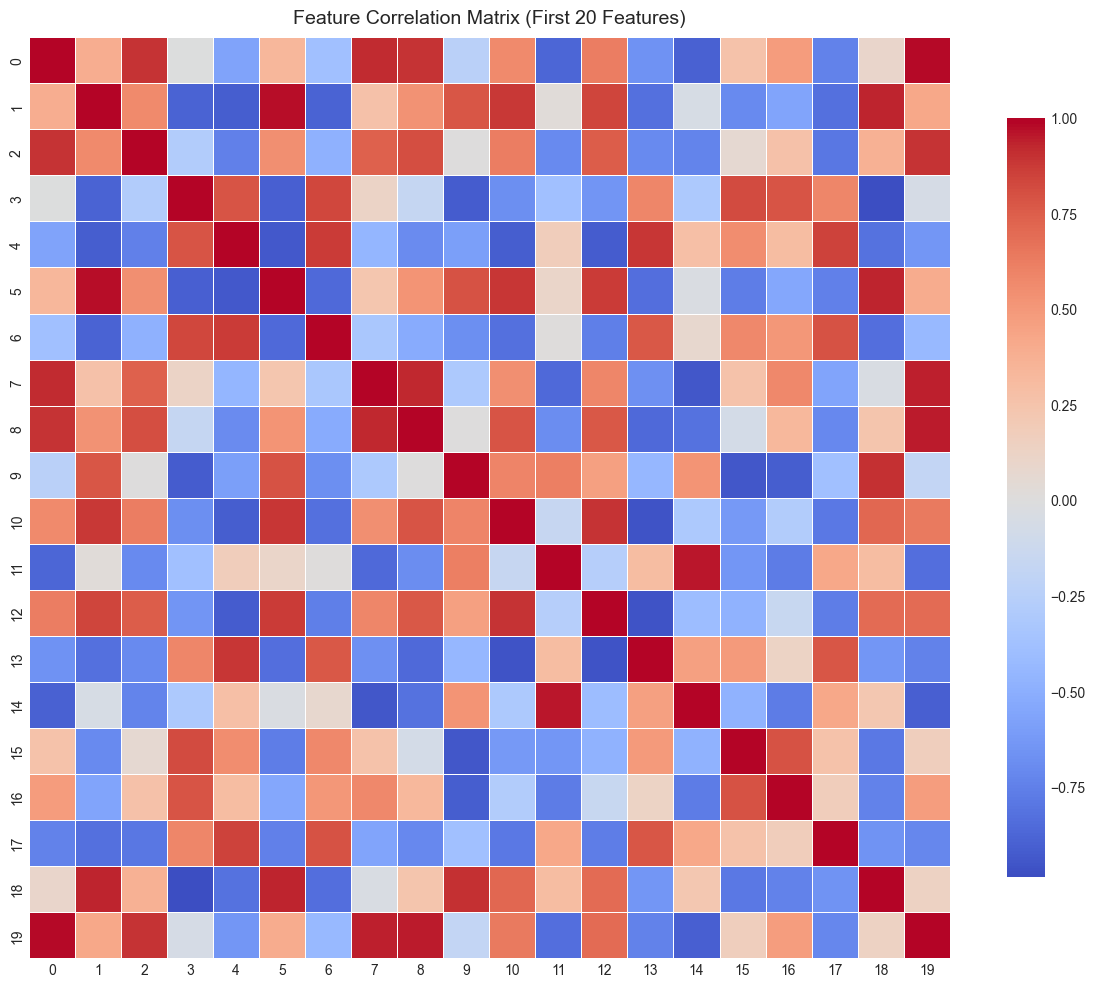

In [15]:
# Correlation matrix for first 20 features (using first sequence)
sample_features = feature_cols[:20]
corr_matrix = first_seq[sample_features].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, cmap='coolwarm', center=0, 
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8},
            xticklabels=True, yticklabels=True)
plt.title('Feature Correlation Matrix (First 20 Features)', fontsize=14, pad=10)
plt.tight_layout()
plt.show()

In [16]:
# Find highly correlated feature pairs
high_corr_threshold = 0.8
corr_pairs = []

for i in range(len(sample_features)):
    for j in range(i+1, len(sample_features)):
        corr_val = corr_matrix.iloc[i, j]
        if abs(corr_val) > high_corr_threshold:
            corr_pairs.append((sample_features[i], sample_features[j], corr_val))

if corr_pairs:
    print(f"\nHighly correlated pairs (|r| > {high_corr_threshold}):")
    for feat1, feat2, corr in sorted(corr_pairs, key=lambda x: abs(x[2]), reverse=True)[:10]:
        print(f"  {feat1} <-> {feat2}: {corr:.3f}")
else:
    print(f"\nNo highly correlated pairs found (|r| > {high_corr_threshold})")


Highly correlated pairs (|r| > 0.8):
  3 <-> 18: -0.986
  0 <-> 19: 0.979
  1 <-> 5: 0.971
  10 <-> 13: -0.961
  12 <-> 13: -0.960
  11 <-> 14: 0.954
  8 <-> 19: 0.949
  9 <-> 15: -0.943
  7 <-> 19: 0.942
  7 <-> 14: -0.940


## 8. Multi-Sequence Comparison

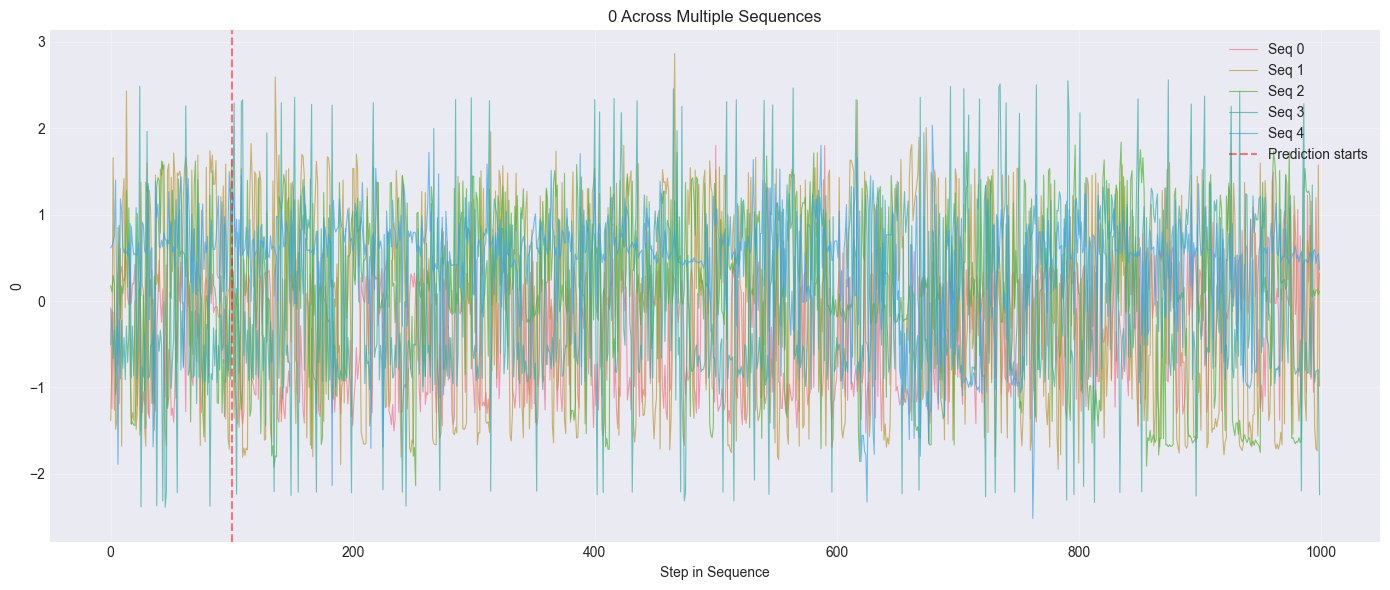

In [17]:
# Compare first feature across multiple sequences
n_sequences_to_plot = min(5, n_sequences)
sample_seq_indices = df['seq_ix'].unique()[:n_sequences_to_plot]

plt.figure(figsize=(14, 6))
for seq_ix in sample_seq_indices:
    seq_data = df[df['seq_ix'] == seq_ix]
    plt.plot(seq_data['step_in_seq'], seq_data[feature_cols[0]], 
             alpha=0.7, linewidth=0.8, label=f'Seq {seq_ix}')

plt.axvline(x=100, color='red', linestyle='--', alpha=0.5, label='Prediction starts')
plt.xlabel('Step in Sequence')
plt.ylabel(feature_cols[0])
plt.title(f'{feature_cols[0]} Across Multiple Sequences')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 9. Summary Statistics

In [18]:
print("=" * 70)
print("DATASET SUMMARY")
print("=" * 70)
print(f"Total samples: {len(df):,}")
print(f"Number of sequences: {n_sequences}")
print(f"Steps per sequence: {len(first_seq)}")
print(f"Number of features: {n_features}")
print(f"Warm-up steps per sequence: {warmup_per_seq:.0f}")
print(f"Prediction steps per sequence: {predictions_per_seq:.0f}")
total_predictions = pred_counts.iloc[pred_counts.index.tolist().index(True)] if True in pred_counts.index else 0
print(f"\nTotal predictions to make: {total_predictions:,}")
print(f"Dataset memory footprint: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

DATASET SUMMARY
Total samples: 517,000
Number of sequences: 517
Steps per sequence: 1000
Number of features: 32
Warm-up steps per sequence: 0
Prediction steps per sequence: 0

Total predictions to make: 0
Dataset memory footprint: 138.05 MB


## 10. Key Insights

**To be filled in after running the analysis:**

1. **Data Structure:**
   - [Number] sequences of [length] steps each
   - [Number] features per timestep
   - Warm-up period: steps 0-99, predictions: steps 100-998

2. **Feature Characteristics:**
   - Scale and distribution patterns
   - Stationarity observations
   - Correlation patterns

3. **Temporal Patterns:**
   - Autocorrelation strength
   - Trend vs. mean-reverting behavior
   - Sequence-to-sequence variability

4. **Modeling Implications:**
   - Need for normalization/scaling?
   - Suggested sequence length for models
   - Feature engineering opportunities